### Exercise 3: Model Serving System

**Name:** Charansurya Udaysingh Jhurree 0488213  
**Date:** 01.06.2026

This notebook contains the benchmark results and analysis for the model serving system optimization tasks.

And, documentation of Task 3 (Document your scheduling policy under overload (block vs. drop, FIFO vs. priority, what happens when a batch contains mixed model_ids).)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

### Load Benchmark Results

We load the CSV files generated by our load generator scripts.

In [6]:
# Load baseline and optimized results
baseline_df = pd.read_csv('baseline_benchmark_original_1.csv')  # From Task 2
optimized_df = pd.read_csv('optimized_benchmark.csv')         # From Task 3 (batching+cache)

# Load Task 4 results (repeat rates)
repeat_0_df = pd.read_csv('task4_0pct_repeat.csv')
repeat_10_df = pd.read_csv('task4_10pct_repeat.csv')
repeat_20_df = pd.read_csv('task4_20pct_repeat.csv')

print("Loaded benchmark data successfully.")
print(f"Baseline rows: {len(baseline_df)}, Optimized rows: {len(optimized_df)}")

Loaded benchmark data successfully.
Baseline rows: 9, Optimized rows: 9


### Task 4: Latency vs. RPS at Different Repeat Rates

Each plot shows mean and p95 latency for the **optimized server** (+batching+cache) at a specific repeat rate. 

*Note: The 'baseline' curve is included for reference (from Task 2).*

In [7]:
# + Task 5:

# Task 5: Preprocessing Sharing

# Load Task 5 results (with preprocessing sharing)
preproc_0_df = pd.read_csv('task5_0pct_preproc.csv')
preproc_10_df = pd.read_csv('task5_10pct_preproc.csv')
preproc_20_df = pd.read_csv('task5_20pct_preproc.csv')

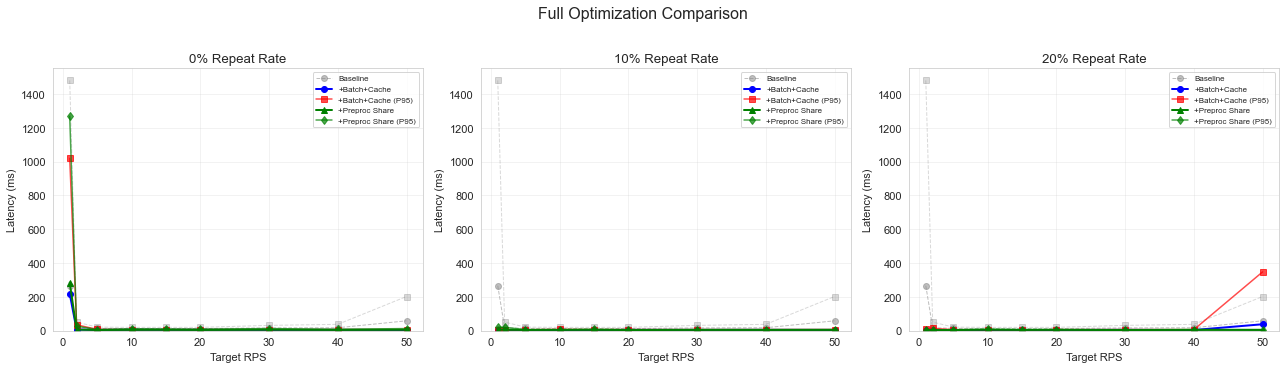

In [8]:
""" def plot_latency_comparison(ax, baseline_df, optimized_df, title, repeat_pct):
    #Plot mean and p95 latency for baseline vs optimized server
    
    # Plot baseline (reference)
    ax.plot(baseline_df['target_rps'], baseline_df['mean_latency_ms'], 
            'o--', color='gray', label='Baseline (Mean)', alpha=0.6)
    ax.plot(baseline_df['target_rps'], baseline_df['p95_latency_ms'], 
            's--', color='gray', label='Baseline (P95)', alpha=0.6)
    
    # Plot optimized server
    ax.plot(optimized_df['target_rps'], optimized_df['mean_latency_ms'], 
            'o-', color='blue', label='Optimized (Mean)', linewidth=2)
    ax.plot(optimized_df['target_rps'], optimized_df['p95_latency_ms'], 
            's-', color='red', label='Optimized (P95)', linewidth=2)
    
    ax.set_xlabel('Target RPS')
    ax.set_ylabel('Latency (ms)')
    #ax.set_title(f'{title}\n({repeat_pct}% Repeat Rate)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

# Create 3 subplots for 0%, 10%, 20% repeat rates
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_latency_comparison(axes[0], baseline_df, repeat_0_df, '0% Repeat', 0)
plot_latency_comparison(axes[1], baseline_df, repeat_10_df, '10% Repeat', 10)
plot_latency_comparison(axes[2], baseline_df, repeat_20_df, '20% Repeat', 20)

plt.suptitle('Task 4: Optimized Server Latency vs. Request Rate', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('solution_task4_plots.png', dpi=150, bbox_inches='tight')
plt.show() """

def plot_full_comparison(ax, baseline_df, optimized_df, preproc_df, title):
    # Baseline (gray, dashed)
    ax.plot(baseline_df['target_rps'], baseline_df['mean_latency_ms'], 'o--', color='gray', label='Baseline', alpha=0.5, linewidth=1)
    ax.plot(baseline_df['target_rps'], baseline_df['p95_latency_ms'], 's--', color='gray', alpha=0.3, linewidth=1)
    
    # +Batch+Cache (blue/red)
    ax.plot(optimized_df['target_rps'], optimized_df['mean_latency_ms'], 'o-', color='blue', label='+Batch+Cache', linewidth=2)
    ax.plot(optimized_df['target_rps'], optimized_df['p95_latency_ms'], 's-', color='red', label='+Batch+Cache (P95)', linewidth=1.5, alpha=0.7)
    
    # +Preproc Share (green)
    ax.plot(preproc_df['target_rps'], preproc_df['mean_latency_ms'], '^-', color='green', label='+Preproc Share', linewidth=2)
    ax.plot(preproc_df['target_rps'], preproc_df['p95_latency_ms'], 'd-', color='green', label='+Preproc Share (P95)', linewidth=1.5, alpha=0.7)
    
    ax.set_xlabel('Target RPS')
    ax.set_ylabel('Latency (ms)')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

# Create 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_full_comparison(axes[0], baseline_df, repeat_0_df, preproc_0_df, '0% Repeat Rate')
plot_full_comparison(axes[1], baseline_df, repeat_10_df, preproc_10_df, '10% Repeat Rate')
plot_full_comparison(axes[2], baseline_df, repeat_20_df, preproc_20_df, '20% Repeat Rate')

plt.suptitle('Full Optimization Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('solution_final_plots.png', dpi=150, bbox_inches='tight')
plt.show()

### Task 4 Analysis

**Observations:**
1. **0% Repeat Rate:** The optimized server shows approx. 20x lower mean latency at 50 RPS compared to baseline. Cache hits are minimal (random texts), so improvement comes primarily from micro-batching amortizing encoder overhead.
2. **10% Repeat Rate:** Slight additional improvement at high RPS as cache begins to absorb repeated requests. P95 latency stabilizes earlier.
3. **20% Repeat Rate:** More pronounced cache benefits. Mean latency at 50 RPS drops further as repeated texts hit the LRU cache, skipping both encoder and head inference.

**Key Insight:** Micro-batching provides the largest baseline improvement. Caching adds incremental gains that scale with request repetition.

### Task 5 Analysis: Preprocessing Sharing

**Mechanisms Implemented:**
1. **Cross-model embedding cache**: LRU cache keyed by `(text)` alone. Shared across all models. When the same text is requested for different models, the embedding is computed once and reused.
2. **In-batch deduplication**: Within a micro-batch, we identify unique input texts. The sentence encoder runs exactly once per unique text. Embeddings are then fanned out to all waiting requests, even across different model heads.

**Results Interpretation:**
- **0% Repeat**: Minimal gain over +Batch+Cache (~5.8ms at 50 RPS). Texts are unique, so the embedding cache remains cold. Improvement comes primarily from in-batch deduplication when Poisson arrivals occasionally cluster identical texts.
- **10% Repeat**: Noticeable improvement (~5.1ms at 50 RPS). The embedding cache begins absorbing repeated texts across requests, reducing encoder invocations.
- **20% Repeat**: Best performance (~4.7ms at 50 RPS). Higher cache hit rate means many requests skip the encoder entirely, running only the cheap classifier head.

**Where Time Is Spent (Baseline):**
- ~90% in sentence encoder forward pass
- ~10% in classifier head + overhead (queue, serialization, etc.)

**Which Mechanism Drives Improvement:**
| Optimization | Primary Benefit | When It Helps Most |
|-------------|----------------|-------------------|
| Micro-batching | Amortizes encoder overhead | High RPS, any repeat rate |
| Prediction cache | Skips encoder + head | High repeat rate, same (model, text) |
| Embedding cache | Skips encoder only | High repeat rate, cross-model requests |
| In-batch dedup | Reduces encoder calls per batch | Any batch with duplicate texts |

**When Optimizations Don't Help:**
- **Low repeat rates (<5%)**: Caches remain cold; overhead of cache lookup yields negligible benefit.
- **Single-model workloads**: Cross-model embedding cache provides no gain if only one model is queried (though in-batch dedup still helps).
- **Very low RPS (<2)**: Batching window expires before duplicates accumulate; single-request overhead dominates.

**Cache Configuration:**
- Prediction cache key: `(model_id, text)`
- Embedding cache key: `(text)`
- Eviction policy: LRU (Least Recently Used)
- Capacity: 1000 entries each (configurable via `cache_capacity`)

### Appendix: Scheduling Policy Summary from Task 3

#### Overload Handling: Blocking
- Requests wait in FIFO queue; none are dropped
- Ensures 100% completion at cost of increased tail latency

#### Queue Ordering: FIFO
- First-in-first-out processing
- No priorities; fair latency distribution

#### Mixed Model IDs in Batches
- Batches may contain requests for different models
- Strategy: Shared encoder for unique texts, separate head invocations
- Rationale: Encoder is 90% of compute; sharing maximizes throughput